<a href="https://colab.research.google.com/github/minuparvathi-byte/India-Asia-Export-Analytics-using-Python/blob/main/India%E2%80%93Asia_Export_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage 1**

# **India–Asia Export Analysis** | **Python** | **2015-2025**

# **Dataset Information**
Source: indiadataportal.com

Location: https://indiadataportal.com/p/export-trade-statistics/r/mci-tradestat_export_lfy-cn-mn-asi

Year/Timeline: 2015-2025

Domain: Commerce

## **Objective**
**Track Trade and Export Trends Over the Years**

Study how India's total trade and exports have changed from year to year, in order to understand whether trade is growing, shrinking, or staying steady over time.

**Compare Country-Wise Trade Performance**

Look at trade data for each individual country to find out:


* Which countries India trades with the most (top trading partners)
* Which countries are showing the fastest growth in trade with India (emerging or rising markets)

**Identify Yearly Patterns and Generate Insights**

Analyze trade data across multiple years to spot patterns, trends, and changes — such as seasonal effects, sudden increases/decreases, or long-term shifts — and turn these findings into clear, useful insights that support better trade-related decisions.


In [57]:
#import libraries
import numpy as np
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

In [2]:
#importing dataset from drive

from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Assignments/Python Main-Project/exports-to-asian-countries.csv'

df = pd.read_csv(
    file_path,
    low_memory=False,
    engine="c"
)
df

Mounted at /content/drive


,id,date,country_name,alpha_3_code,country_code,region_name,region_code,subregion_name,subregion_code,hs_code,commodity,unit,value_qt,value_rs,value_dl
0,0,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,2023000,"Boneless Meat Of Bovine Animals , Frozen",Kgs,337.00,347.09,0.56
1,1,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,3061719,Other Scampi,Kgs,0.64,2.92,0.00
2,2,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,4021010,Skimmed Milk,Kgs,32.00,71.66,0.12
3,3,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,4021090,"Other Mlk And Crm In Pwdr,Granl Or Solid Frm O...",Kgs,25.00,56.83,0.09
4,4,2015-01-01,Afghanistan,AFG,4,Asia,142,Southern Asia,34,4022920,Milk For Babies,Kgs,7.96,23.38,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5541804,5541804,2025-10-01,Yemen,YEM,887,Asia,142,Western Asia,145,96083099,Other Pens Of Hdg. 9608,Nos,28800.00,0.01,0.00
5541805,5541805,2025-10-01,Yemen,YEM,887,Asia,142,Western Asia,145,96091000,"Pencils And Crayons,With Leads Encased In A Sh...",Kgs,23345.00,0.81,0.09
5541806,5541806,2025-10-01,Yemen,YEM,887,Asia,142,Western Asia,145,96122000,Ink-Pads,Nos,310.00,0.02,0.00
5541807,5541807,2025-10-01,Yemen,YEM,887,Asia,142,Western Asia,145,96138090,Others,Nos,47600.00,0.09,0.01


In [3]:
df.shape

(5541809, 15)

In [4]:
df.info()  #viewing the info of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5541809 entries, 0 to 5541808
Data columns (total 15 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   country_name    object 
 3   alpha_3_code    object 
 4   country_code    int64  
 5   region_name     object 
 6   region_code     int64  
 7   subregion_name  object 
 8   subregion_code  int64  
 9   hs_code         int64  
 10  commodity       object 
 11  unit            object 
 12  value_qt        float64
 13  value_rs        float64
 14  value_dl        float64
dtypes: float64(3), int64(5), object(7)
memory usage: 634.2+ MB


In [5]:
df.columns  #viewing the column names

Index(['id', 'date', 'country_name', 'alpha_3_code', 'country_code',
       'region_name', 'region_code', 'subregion_name', 'subregion_code',
       'hs_code', 'commodity', 'unit', 'value_qt', 'value_rs', 'value_dl'],
      dtype='object')

In [6]:
df.dtypes  #checking the data types

,0
id,int64
date,object
country_name,object
alpha_3_code,object
country_code,int64
region_name,object
region_code,int64
subregion_name,object
subregion_code,int64
hs_code,int64


In [7]:
df.describe() #summary statistics

,id,country_code,region_code,subregion_code,hs_code,value_qt,value_rs,value_dl
count,5541809.00,5541809.00,5541809.00,5541809.00,5541809.00,5496520.00,5541785.00,5258921.00
mean,2770904.00,446.43,142.00,72.20,55710728.18,55328.98,130.56,0.25
std,1599782.60,247.59,0.00,53.11,26377331.69,3942736.20,3052.00,4.90
min,0.00,4.00,142.00,30.00,1012100.00,0.00,0.00,0.00
25%,1385452.00,158.00,142.00,34.00,32041321.00,0.15,0.24,0.00
50%,2770904.00,458.00,142.00,35.00,59031090.00,3.00,2.82,0.01
75%,4156356.00,682.00,142.00,145.00,84158390.00,51.18,22.48,0.06
max,5541808.00,887.00,142.00,145.00,99999998.00,2046346818.00,977886.92,1517.49


In [8]:
df.isnull().sum()  #checking for a null values

,0
id,0
date,0
country_name,0
alpha_3_code,0
country_code,0
region_name,0
region_code,0
subregion_name,0
subregion_code,0
hs_code,0


In [9]:
df.duplicated().sum()   #viewing sum of duplicated values

np.int64(0)


# **Stage 2**

**Data Cleaning,Data Transformation  and Feature Engineering**

Handle duplicates

Handle missing values (impute or drop)

column name rename or dropping unwanted columns


Stage 2
Data Cleaning,Data Transformation and Feature Engineering

Handle duplicates

Handle missing values (impute or drop)

column name rename or dropping unwanted columns

Treat outliers if required(optional)

Convert data types if needed

Data Transformation or Data Wrangling

Final EDA

In [10]:
#changing column names to uppercase
df.columns = df.columns.str.upper()
df.columns

Index(['ID', 'DATE', 'COUNTRY_NAME', 'ALPHA_3_CODE', 'COUNTRY_CODE',
       'REGION_NAME', 'REGION_CODE', 'SUBREGION_NAME', 'SUBREGION_CODE',
       'HS_CODE', 'COMMODITY', 'UNIT', 'VALUE_QT', 'VALUE_RS', 'VALUE_DL'],
      dtype='object')

In [11]:
#handling duplicates
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
#renaming specific column names
df.rename(columns={"VALUE_QT": "QUANTITY","VALUE_DL":"VALUE_USD"}, inplace=True)
df.columns

Index(['ID', 'DATE', 'COUNTRY_NAME', 'ALPHA_3_CODE', 'COUNTRY_CODE',
       'REGION_NAME', 'REGION_CODE', 'SUBREGION_NAME', 'SUBREGION_CODE',
       'HS_CODE', 'COMMODITY', 'UNIT', 'QUANTITY', 'VALUE_RS', 'VALUE_USD'],
      dtype='object')

In [13]:
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

Handling Null Values | Categorical Column


In [14]:
#handlling null values in unit column
print('Total null values:',df['UNIT'].isnull().sum())
print(df['UNIT'].unique())

Total null values: 5868
['Kgs' 'Nos' 'Sqm' 'Prs' 'Unt' nan 'Ltr' 'Thd' 'Cbm' 'Ton' 'Ctm' 'Crt'
 'Mtr' 'Mts' 'Thn' 'Cum' 'Gif' 'Tkw' 'Kg' '"']


In [15]:
#repalcing errors values
df['UNIT'] = df['UNIT'].replace({
    'Kg': 'Kgs',
    'Mts': 'Mtr',
    'Cum': 'Cbm',
    'Thn': 'Thd',
    '"': 'Unknown',
})

df['UNIT'] = df['UNIT'].fillna('Unknown')


In [61]:
#cleaning commodity column
commodities = df['COMMODITY'].dropna().unique()

print("Total unique commodities:", len(commodities))

for commodity in commodities[:200]:
    print(commodity)

Total unique commodities: 11045
Boneless Meat Of Bovine Animals , Frozen
Other Scampi
Skimmed Milk
Other Mlk And Crm In Pwdr,Granl Or Solid Frm Of Fat Contnt, By Wt. Not Excdng 1.5%
Milk For Babies
Of Fowls Of The Species Gallus Domesticus
Roses
Lilies (Lilium Spp.)
Other Of Hdg. 0604
*Mixed Vegetables
Bananas, Fresh
Tea Black,Leaf In Bulk
Othr Pepper Nthr Crshd Nor Grnd
Basmati Rice
Starch Of Maize (Corn)
Other Food Prpns Fr Infnt Use Excl Malted Milk
Other Nuts Otherwise Prpd/Prsd
Soft Drink - Other Than Sharbat
Pan-Masala Including Scented Supari (Betel Spices Prepared)
Chewing Tobacco
Jarda Scented Tobacco
Other Mnfrd Tobacco Extrcts And Essncs Nes
Plasters Other Than Calcined
Other Petroleum Jelly
Other
Metronidazole Metronidiazole Benzoate
Halgntd Drvtvs Of Corti Costeroidal
Other Antibiotics
Other Diloxanide Furoate, Cimetidine, Famotidine Nes
Mdcmnts Cntng Pnclns/Thr Drvtvs With A/Pnclnc Acd Strctre,Strptmcns/Thr Drvts
Other, Containing Antibiotics
Anaesthetic Agents Used In Hu

In [17]:
#copy of commodity col
df["CLEAN_COMMODITY"] = df['COMMODITY']

In [18]:
import re
df["CLEAN_COMMODITY"] = (
    df["COMMODITY"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace("*", " ", regex=False)
    .str.replace("-", " ", regex=False)
    .str.replace("/", " ", regex=False)
    .str.replace(r"\.+", ".", regex=True)
)

In [19]:
replacements = {
    "Mlk": "Milk",
    "Crm": "Cream",
    "Pwdr": "Powder",
    "Granl": "Granules",
    "Frm": "Form",
    "Othr": "Other",
    "Nes": "NES",
    "N.E.S": "NES",
    "Mdcmnts": "Medicaments",
    "Medcne": "Medicine",
    "Prpd": "Prepared",
    "Prsd": "Preserved",
    "Pckng": "Packing",
    "Cnvynce": "Conveyance",
    "Artcls": "Articles",
    "Pntmc": "Pneumatic",
    "Pnmnc": "Pneumatic",
    "Plstcs": "Plastics",
    "Hrd": "Hard",
    "Rubr": "Rubber",
    "Ointmnts": "Ointments",
    "Dervativs": "Derivatives",
    "Capsul": "Capsules",
    "Tblts": "Tablets",
    "Antiinflamatory": "Anti-inflammatory",
    "Analgestics": "Analgesics",
    "Antipyratic": "Antipyretic"
}

for old, new in replacements.items():
    df["CLEAN_COMMODITY"] = df["CLEAN_COMMODITY"].str.replace(
        old, new, regex=False, case=False
    )

In [20]:
#creating category-wise for better analyse

df["COMMODITY_CATEGORY"] = "Other"

#food & agriculture
food_pattern = (
    r"rice|milk|cream|meat|beef|scampi|fish|prawn|seafood|"
    r"banana|tea|pepper|spice|vegetable|fruit|nut|starch|"
    r"food|infant|baby|cereal|grain|wheat|maize|corn|"
    r"sugar|coffee|cocoa|flour|bread|biscuit|soft drink|"
    r"beverage|juice|edible|oil|food preparation"
)


df.loc[
    df["CLEAN_COMMODITY"].str.contains(food_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Food & Agriculture"


In [21]:
#paper products
paper_pattern = (
    r"paper|paperboard|cardboard|corrugated|"
    r"carton|paper box|paper bag|paper sack|"
    r"filter paper|printed paper|calendar|"
    r"advertising matter|laminate"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(paper_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Paper & Paper Products"

In [22]:
#tobacco & related products
tobacco_pattern = (
    r"tobacco|cigarette|cigar|pan masala|supari|"
    r"chewing tobacco|jarda|scented tobacco"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(tobacco_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Tobacco & Related Products"

In [23]:
#rubber & tyres
rubber_pattern = (
  r"rubber|tyre|tire|inner tube|pneumatic|"
  r"tyre flap|rubber contraceptive|condom"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(rubber_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Rubber & Tyres"

In [24]:
#textiles & Fabrics
textile_pattern = (
    r"cotton waste|cotton fabric|cotton yarn|"
    r"polyester fabric|polyester fibre|polyester yarn|"
    r"synthetic fabric|synthetic fibre|synthetic filament|"
    r"viscose|rayon|silk|wool|textile|fabric|"
    r"woven fabric|lace|embroidery|cordage|rope|"
    r"twine|shawl|scarf|muffler"
)

df.loc[
     df["CLEAN_COMMODITY"].str.contains(textile_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Textiles & Fabrics"

In [25]:
#apparel & garments
apparel_pattern = (
    r"saree|shirt|t-shirt|trouser|shorts|jacket|"
    r"blazer|suit|dress|skirt|blouse|pyjama|"
    r"nightshirt|nightdress|brief|panties|"
    r"petticoat|slip|jersey|sweater|cardigan|"
    r"garment|clothing|ensemble|hosiery|"
    r"babies garment|kurta|salwar|duppatta|"
    r"overalls|breeches"
)

df.loc[
     df["CLEAN_COMMODITY"].str.contains(apparel_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Apparel & Garments"

In [26]:
#cosmetics & personal care
cosmetic_pattern = (
    r"shampoo|hair oil|hair dye|cosmetic|talcum|"
    r"perfume|deodorant|beauty|soap|skin care|"
    r"bindi|kumkum|sindur|petroleum jelly|"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(cosmetic_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Cosmetics & Personal Care"

In [27]:
#leather & travel goods
leather_pattern = (
    r"leather|wallet|purse|belt|bandolier|"
    r"travel goods|trunk|suitcase|handbag|"
    r"leather case|leather bag"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(leather_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Leather & Travel Goods"

In [28]:
#plastic products
plastic_pattern = (
    r"plastic|polyethylene|polypropylene|polyvinyl|"
    r"plastic article|plastic box|plastic bag|"
    r"plastic sack|plastic container|plastic sheet|"
    r"plastic film|plastic pipe|plastic tube|"
    r"plastic hose"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(plastic_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Plastics"

In [29]:
#wooden products
wood_pattern = (
    r"wood|wooden|veneer|timber|"
    r"kitchenware of wood|match sticks"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(wood_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Wood & Wooden Products"

In [30]:
#packaging
packaging_pattern = (
    r"sack|bag|packing|container|crate|box|"
    r"case|carton|packaging"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(packaging_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Packaging"

In [31]:
#jeweller & accessories
jewellery_pattern = (
    r"bangle|jewellery|jewelry|necklace|earring|"
    r"bracelet|comb|hair clip|hanger"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(jewellery_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Jewellery & Accessories"

In [32]:
#stationary
stationery_pattern = (
    r"pencil|crayon|pen|ink pad|stationery|"
    r"writing|eraser|notebook|calendar|"
    r"printed|printing|advertising matter"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(stationery_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Stationery"

In [33]:
#pharmaceuticals
pharma_pattern = (
    r"metronidazole|antibiotic|medicament|medicine|"
    r"penicillin|amoxicillin|ampicillin|ciprofloxacin|"
    r"cephalosporin|sulfonamide|fluoroquinolone|"
    r"oxytetracycline|chloramphenicol|erythromycin|"
    r"azithromycin|clindamycin|corticosteroid|"
    r"prednisolone|dexamethasone|vitamin|analgesic|"
    r"antihypertensive|antibacterial|antacid|antiulcer|"
    r"anticancer|ibuprofen|aspirin|paracetamol|"
    r"isoniazid|salbutamol|tranquilizer|antifungal|"
    r"anthelmintic|antiprotozoal|anaesthetic|"
    r"gonadotrophin|erythropoietin|vaccine|"
    r"pharmaceutical|drug|therapeutic"

)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(pharma_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Pharmaceuticals"

In [34]:
#medical & healthcare equipment
medical_pattern = (
    r"first aid|medical equipment|surgical|"
    r"hospital|medical"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(medical_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Medical & Healthcare Equipment"

In [35]:
#agriculture & plantation
agri_pattern = (
    r"rose|lily|flower|plant|seed|vegetable|fruit|"
    r"banana|cotton|tobacco leaf|agricultural|"
    r"tea leaf|coffee bean|natural rubber"
)

df.loc[
    df["CLEAN_COMMODITY"].str.contains(agri_pattern, case=False, na=False),
    "COMMODITY_CATEGORY"
] = "Agriculture & Plantation"

In [36]:
print(df["COMMODITY_CATEGORY"].value_counts())

COMMODITY_CATEGORY
Cosmetics & Personal Care         4739033
Agriculture & Plantation           284633
Packaging                          122424
Pharmaceuticals                    115165
Plastics                            87569
Stationery                          77738
Jewellery & Accessories             44891
Leather & Travel Goods              29648
Wood & Wooden Products              25012
Medical & Healthcare Equipment      15696
Name: count, dtype: int64


Handling Null Values | Numerical columns

In [37]:
#handling null values in quantity col
print('Total null value:', df['QUANTITY'].isnull().sum())
print(df['QUANTITY'].describe())

Total null value: 45289
count      5496520.00
mean         55328.98
std        3942736.20
min              0.00
25%              0.15
50%              3.00
75%             51.18
max     2046346818.00
Name: QUANTITY, dtype: float64


In [38]:
df['QUANTITY'] = df['QUANTITY'].fillna(df['QUANTITY'].median())

In [39]:
#handlinlg null values in value_rs
print('Total null values:',df['VALUE_RS'].isnull().sum())
df['VALUE_RS'].describe()

Total null values: 24


,VALUE_RS
count,5541785.00
mean,130.56
std,3052.00
min,0.00
25%,0.24
50%,2.82
75%,22.48
max,977886.92


In [40]:
df['VALUE_RS'] = df['VALUE_RS'].fillna(df['VALUE_RS'].median())

In [41]:
#drop value_usd
df.drop(['VALUE_USD','REGION_CODE','SUBREGION_CODE'],axis=1, inplace=True, errors='ignore')

# **Stage 3**


# **Statistical analysis & Visualizations**

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

Interpretation MUST with every visualization

Focus on business story not just charts

Each chart must be in seperate cells.

In [42]:
# MEASURE OF CENTRAL TENDENCY
columns = ["QUANTITY","VALUE_RS"]

central_tendency = pd.DataFrame({
    "Mean": df[columns].mean(),
    "Median": df[columns].median(),
    "Mode": df[columns].mode().iloc[0]
})
print("Measure of Central Tendency")
print(central_tendency)

Measure of Central Tendency
             Mean  Median  Mode
QUANTITY 54876.85    3.00  0.00
VALUE_RS   130.56    2.82  0.00


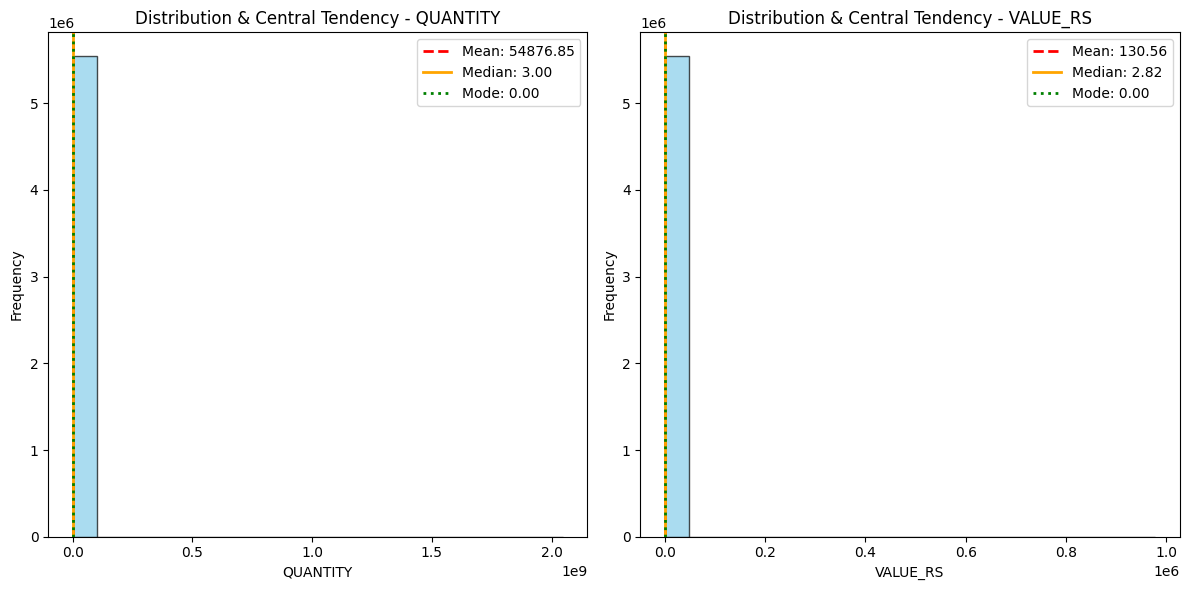

In [43]:
# Visualization for Distribution and Central Tendency
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, col in zip(axes, columns):
    # Plot data distribution as a histogram
    ax.hist(df[col], bins=20, color="skyblue", edgecolor="black", alpha=0.7)

    # Extract measures from central_tendency DataFrame
    mean_val = central_tendency.loc[col, "Mean"]
    median_val = central_tendency.loc[col, "Median"]
    mode_val = central_tendency.loc[col, "Mode"]

    # Overlay lines for central tendency measures
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, color="orange", linestyle="-", linewidth=2, label=f"Median: {median_val:.2f}")
    ax.axvline(mode_val, color="green", linestyle=":", linewidth=2, label=f"Mode: {mode_val:.2f}")

    # Chart styling
    ax.set_title(f"Distribution & Central Tendency - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

# Interpretation of the Measure of Central Tendency Chart


* **Quantity:** The mean is 54,876.85, while the median is only 3 and the mode is 0. This large difference indicates that the Quantity data is highly right-skewed. A relatively small number of very large transactions are pulling the mean upward.
* **Value_RS:** The mean is 130.56, compared with a median of 2.82 and a mode of 0. This also indicates a strong right-skewed distribution, where some transactions have much higher values than most observations.
* For both variables, Mode = 0, meaning zero is the most frequently occurring value in the dataset.
* Since Mean > Median > Mode for both Quantity and Value_RS, the data shows a clear positive/right skewness.









In [44]:
# Variance and Standard Deviation

variance_std = pd.DataFrame({
    "Variance": df[columns].var(),
    "Standard Deviation": df[columns].std()
})

print("Variance and Standard Deviation")
print(variance_std)

Variance and Standard Deviation
                  Variance  Standard Deviation
QUANTITY 15418154629760.03          3926595.81
VALUE_RS        9314660.08             3051.99


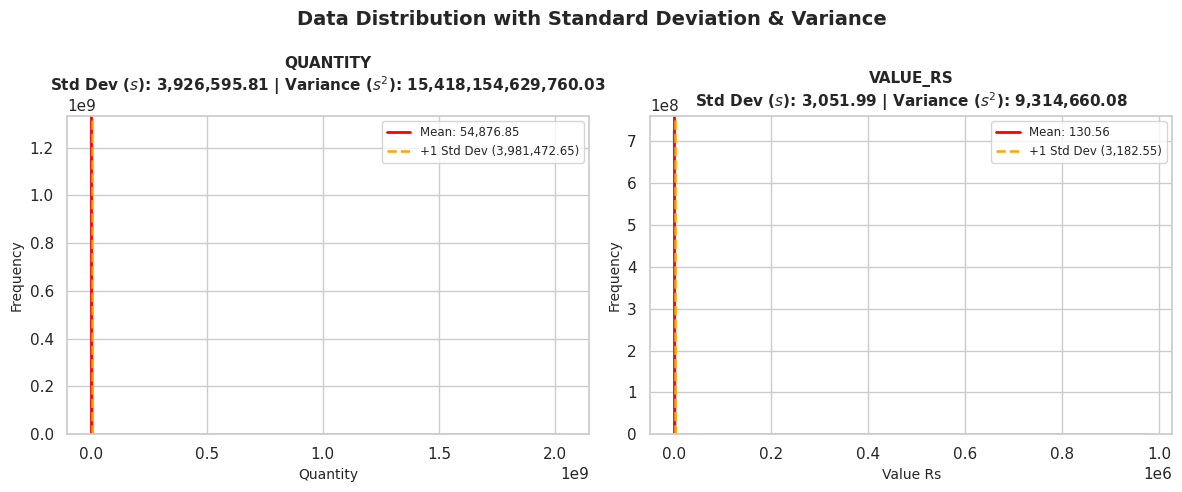

In [45]:
# Set professional theme
sns.set_theme(style="whitegrid")

# Columns to visualize
columns = ["QUANTITY", "VALUE_RS"]

# Create 1x2 subplot layout (one histogram per column)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Data Distribution with Standard Deviation & Variance",
    fontsize=14,
    weight="bold",
)

# Loop through columns and generate histograms
for ax, col in zip(axes, columns):
    # Calculate statistics
    mean_val = df[col].mean()
    std_val = df[col].std()
    var_val = df[col].var()

    # 1. Plot Histogram with KDE curve
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=ax,
        color="skyblue",
        alpha=0.5,
        edgecolor="white",
        bins=20,
    )

    # 2. Add Mean Line
    ax.axvline(
        mean_val,
        color="red",
        linestyle="-",
        linewidth=2,
        label=f"Mean: {mean_val:,.2f}",
    )

    # 3. Add Standard Deviation Lines (+/- 1 Std Dev)
    ax.axvline(
        mean_val + std_val,
        color="orange",
        linestyle="--",
        linewidth=1.8,
        label=f"+1 Std Dev ({mean_val + std_val:,.2f})",
    )


    # Styling & Labels
    ax.set_title(
        f"{col}\nStd Dev ($s$): {std_val:,.2f} | Variance ($s^2$): {var_val:,.2f}",
        fontsize=11,
        weight="bold",
    )
    ax.set_xlabel(col.replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.legend(frameon=True, facecolor="white", loc="upper right", fontsize=8.5)

plt.tight_layout()
plt.show()

# Interpretation of the above chart
* Quantity has a very high variance, which indicates that the quantity exported varies significantly across transactions.

* The standard deviation of Quantity is 3,926,595.81, showing that
individual quantities can differ substantially from the average quantity.
* Value_RS has a much smaller variance and standard deviation compared with Quantity, indicating relatively less dispersion in the values.

* The standard deviation of Value_RS is 3,051.99, meaning the export values show less variation than the quantity data.

* Overall, Quantity is more widely dispersed and has greater variability, while Value_RS is comparatively more consistent.

* The large difference in scale between variance and standard
deviation is expected because variance is expressed in squared units, while standard deviation is expressed in the original units.






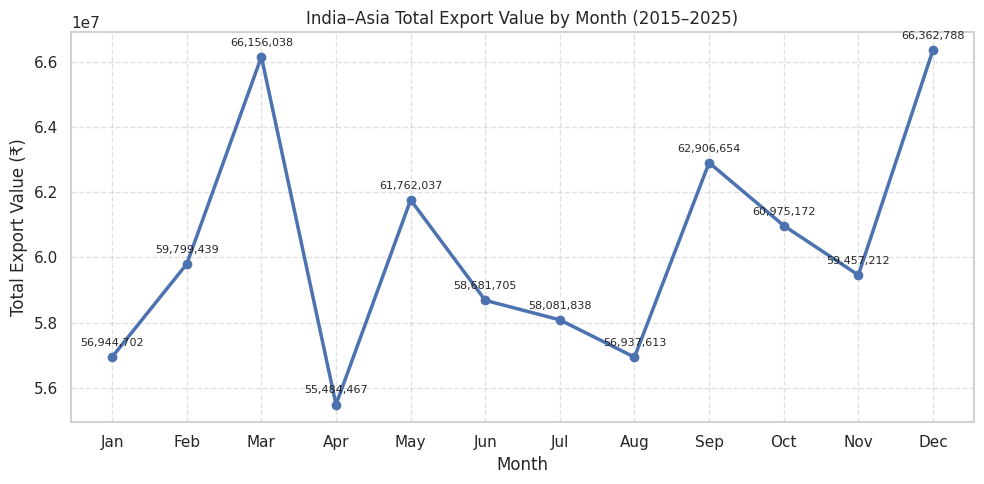

In [54]:
# Extract month
df["MONTH"] = df["DATE"].dt.month

# Calculate total revenue by month
monthly_rev = (
    df.groupby("MONTH")["VALUE_RS"]
      .sum()
      .reset_index()
)

# Convert month number to month name
monthly_rev["MONTH_NAME"] = pd.to_datetime(
    monthly_rev["MONTH"],
    format="%m"
).dt.strftime("%b")

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_rev["MONTH_NAME"],
    monthly_rev["VALUE_RS"],
    marker="o",
    linewidth=2.5
)

plt.title(
    "India–Asia Total Export Value by Month (2015–2025)",
    fontsize=12
)

plt.xlabel("Month")
plt.ylabel("Total Export Value (₹)")

plt.grid(True, linestyle="--", alpha=0.6)

# Add annotations
for x, y in zip(
    monthly_rev["MONTH_NAME"],
    monthly_rev["VALUE_RS"]
):
    plt.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()




**Interpretaion for the chart:**

**Peak Months (Highest Sales):**


* December is the top-performing month of the year, reaching the highest total
export value of ₹66,362,788 (~₹6.64 crore).
* March comes in a very close second at ₹66,156,038 (~₹6.62 crore).
* Why this happens: March marks the end of the financial year in India (a common time to fulfill targets and clear orders), while December aligns with global year-end holiday demand.

**Lowest Month (The Dip):**


* April records the lowest export value of the entire year at ₹55,404,467 (~₹5.54 crore).

* Why this happens: After the heavy rush in March, business activity typically resets and slows down at the start of the new financial year in April.

**Mid-Year Patterns:**


* May Bounce Back: Exports pick right back up in May to ₹61.76M.
* Summer Slowdown (June–August): Exports steadily drift downward through the summer, hitting a minor low point in August (₹56.94M).
* Autumn Boost (September): Activity rebounds sharply in September (₹62.91M) before tapering off slightly through October and November.







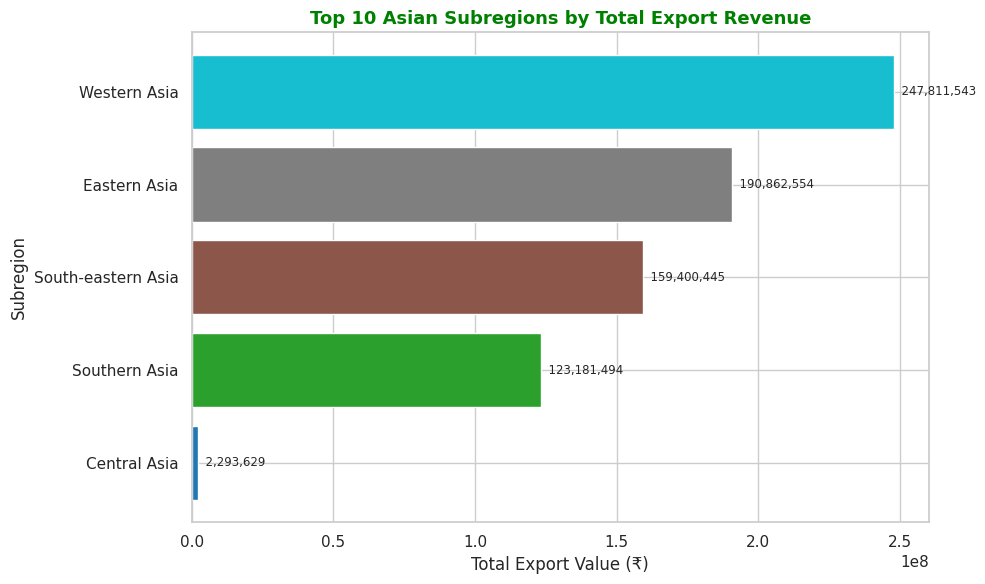

In [56]:
#Objective 2: Identify Top subregion by Export Revenue
# Top Subregions by Export Value
top10_subregions = (
    df.groupby("SUBREGION_NAME")["VALUE_RS"]
      .sum()
      .nlargest(10)
      .sort_values(ascending=True)
      .reset_index()
)

plt.figure(figsize=(10, 6))

# Generate colors
colors = cm.tab10(np.linspace(0, 1, len(top10_subregions)))

# Horizontal bar chart
bars = plt.barh(
    top10_subregions["SUBREGION_NAME"],
    top10_subregions["VALUE_RS"],
    color=colors
)

# Title and labels
plt.title(
    "Top 10 Asian Subregions by Total Export Revenue",
    fontsize=13,
    fontweight="bold",
    color="green"
)

plt.xlabel("Total Export Value (₹)")
plt.ylabel("Subregion")

# Add value labels
for bar in bars:
    w = bar.get_width()

    plt.text(
        w,
        bar.get_y() + bar.get_height() / 2,
        f"  {w:,.0f}",
        va="center",
        fontsize=8.5
    )

plt.tight_layout()
plt.show()

**Interpretation for the chart:**

**1 Top Performing Subregion (Western Asia):**

* Western Asia (the Middle East, including the UAE, Saudi Arabia, Turkiye, etc.) is India's largest market by far, generating ₹247,811,543 (~₹24.78 crore).
* This subregion alone accounts for the single biggest chunk of total Asian export revenue, driven heavily by top destination markets like the UAE.

**Strong 2nd & 3rd Place Regions:**

* Eastern Asia (China, Hong Kong, etc.) takes 2nd place with ₹190,862,554 (~₹19.09 crore).

* South-eastern Asia (Singapore, Viet Nam, Malaysia, etc.) ranks 3rd with ₹159,400,445 (~₹15.94 crore).

**Immediate Neighbors (Southern Asia):**

* Southern Asia (neighbors like Bangladesh, Nepal, etc.) holds 4th place at ₹123,181,494 (~₹12.32 crore), demonstrating solid demand across neighboring trade corridors.

**Massive Gap at the Bottom (Central Asia):**

* Central Asia ranks 5th with only ₹2,293,629 (~₹0.23 crore).





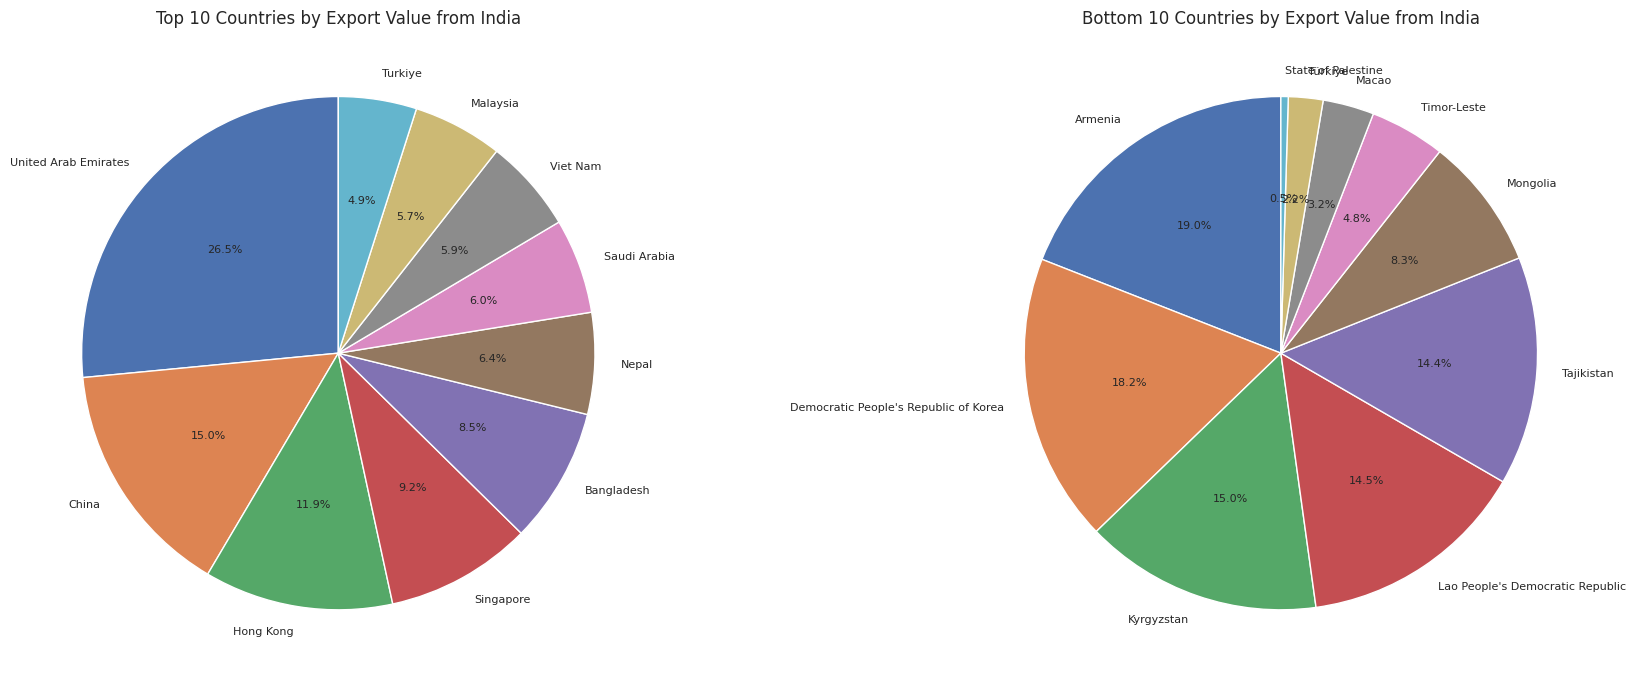

In [55]:
#Objective 3: Evaluate Geographic Trade Share Across Countries
# Total export value by country
country_export = (
    df.groupby("COUNTRY_NAME")["VALUE_RS"]
      .sum()
      .sort_values(ascending=False)
)

# Top and Bottom 10
top_10 = country_export.head(10)
bottom_10 = country_export.tail(10).sort_values(ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))


# Top 10
axes[0].pie(
    top_10,
    labels=top_10.index,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 8}
)

axes[0].set_title(
    "Top 10 Countries by Export Value from India",
    fontsize=12
)


# Bottom 10
axes[1].pie(
    bottom_10,
    labels=bottom_10.index,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 8}
)

axes[1].set_title(
    "Bottom 10 Countries by Export Value from India",
    fontsize=12
)


plt.tight_layout()
plt.show()

**Interpretation for this chart:**

**Left Chart: Top 10 Destinations (Where Most Money Comes From)**

* UAE Controls Over a Quarter: The United Arab Emirates (26.5%) makes up more than 1 in every 4 rupees earned within the top group.

* Top 3 Dominate: UAE (26.5%), China (15.0%), and Hong Kong (11.9%) together account for over 53% of all revenue in the top tier.

* Balanced Lower Tier: The remaining 7 countries (Singapore down to Turkiye) hold smaller, evenly distributed shares ranging between 4.9% and 9.2%.

**Right Chart: Bottom 10 Destinations (Niche & Low-Volume Markets)**

* Top 4 in this Low Tier: Within the 10 smallest trade partners, Armenia (19.0%), Democratic People's Republic of Korea (18.2%), Kyrgyzstan (15.0%), and Lao PDR (14.5%) account for over two-thirds of the lower group's combined volume.

* Tiny Trade Slices at the Bottom: State of Palestine (0.5%) and Turkmenistan (0.2%) represent the absolute smallest export shares in this dataset.

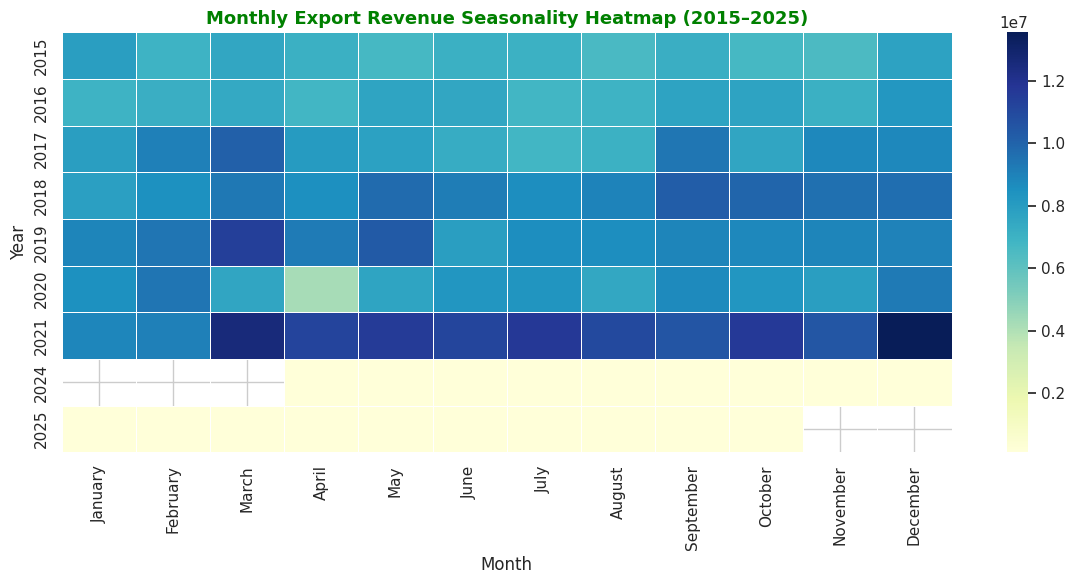

In [49]:
#Objective 4: Uncover Monthly Trade Seasonality Across Years
df["MONTH"] = df["DATE"].dt.month_name()
months_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

seasonality_pivot = df.pivot_table(
    index="YEAR", columns="MONTH", values="VALUE_RS", aggfunc="sum"
).reindex(columns=months_order)

plt.figure(figsize=(12, 6))
sns.heatmap(seasonality_pivot, cmap="YlGnBu", cbar=True, linewidths=0.5)
plt.title(
    "Monthly Export Revenue Seasonality Heatmap (2015–2025)",
    fontsize=13,
    fontweight="bold",
    color="green",
)
plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

**Interpretation for the chart:**

**The "March Surge" Pattern (2017–2021):**

* March consistently stands out as a dark blue hotspot across almost every year (notably 2017, 2019, and 2021).

* This confirms a strong year-end financial push where companies meet targets before the Indian financial year closes on March 31.

**2021 was a Boom Year:**

* 2021 features the darkest blues overall, showing the highest total monthly export revenues in the dataset.

* December 2021 reached the absolute peak value across the entire 10-year period (darkest square near 1.3 × 10⁷ ₹).

**The April 2020 COVID Drop:**

* April 2020 appears in light green—a sharp contrast to surrounding months.

* This reflects the massive trade shutdown caused by global and domestic pandemic lockdowns introduced in late March/April 2020.

/tmp/ipykernel_407/425752119.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_by_cat, vert=False, patch_artist=True, labels=categories_order, showfliers=False)


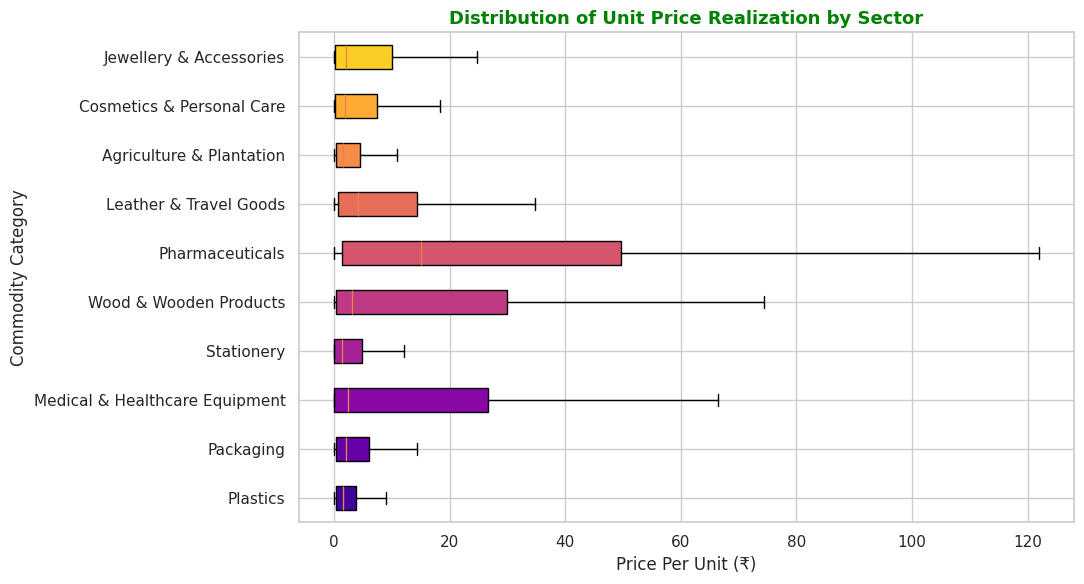

In [50]:
#Objective 5: Compare Unit Value Realization ($\text{Value}/\text{Quantity}$) Across Sectors
# Calculate unit price per shipment line
df["UNIT_PRICE"] = df["VALUE_RS"] / (df["QUANTITY"].replace(0, pd.NA))

unit_price_sector = (
    df.groupby("COMMODITY_CATEGORY")["UNIT_PRICE"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
colors = cm.plasma(np.linspace(0.1, 0.9, len(unit_price_sector)))

plt.figure(figsize=(11, 6))
categories_order = unit_price_sector["COMMODITY_CATEGORY"].tolist()
data_by_cat = [df.loc[df["COMMODITY_CATEGORY"] == cat, "UNIT_PRICE"].dropna() for cat in categories_order]
bp = plt.boxplot(data_by_cat, vert=False, patch_artist=True, labels=categories_order, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
plt.title("Distribution of Unit Price Realization by Sector", fontsize=13, fontweight="bold",color="green")
plt.xlabel("Price Per Unit (₹)")
plt.ylabel("Commodity Category")
plt.tight_layout()
plt.show()

**Interpretation for the chart:**

**Highest Price Spread & Variability (Pharmaceuticals):**


* Pharmaceuticals has the widest spread by far, with prices stretching up to ~₹122 per unit.

* Why this happens: The sector includes everything from low-cost generic drugs to high-value specialized medicine, creating massive price variation per unit.

**High Upper-Range Value Sectors:**


* Wood & Wooden Products (up to ~₹75/unit) and Medical & Healthcare Equipment (up to ~₹67/unit) also show long right-side whiskers.

* While their typical (median) prices remain low, high-end specialized items drive up unit realization in top-tier shipments.

**Low-Margin / Low Unit Price Sectors:**


* Sectors like Plastics, Packaging, Stationery, and Agriculture & Plantation have very narrow boxes clustered near ₹0 – ₹10 per unit.

* These represent high-volume bulk goods where earnings depend on total quantity sold rather than high price per individual unit.

**Consistent Consumer Goods:**

Jewellery & Accessories and Cosmetics & Personal Care maintain moderate, stable spreads (ranging up to ~₹25 and ~₹18/unit), reflecting consistent pricing across shipments.

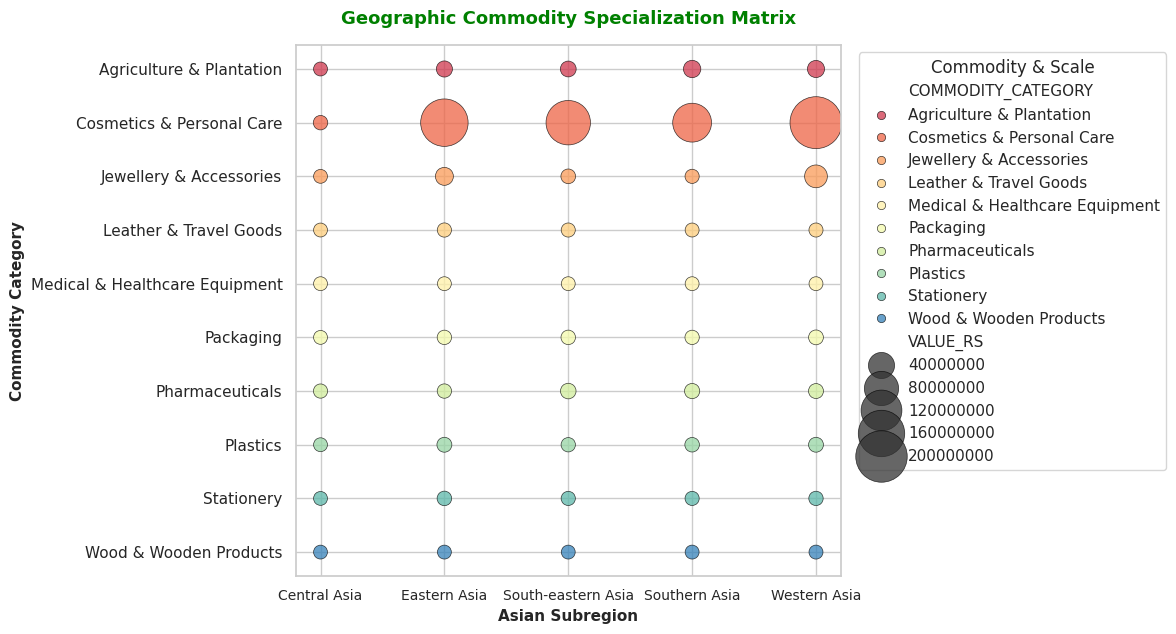

In [51]:
#Objective 6: Analyze Commodity Specialization Across Asian Subregions
#1. Aggregate export value by Subregion and Category
bubble_df = (
    df.groupby(["SUBREGION_NAME", "COMMODITY_CATEGORY"])["VALUE_RS"]
    .sum()
    .reset_index()
)

# Filter out zero/null trade pairs
bubble_df = bubble_df[bubble_df["VALUE_RS"] > 0]

# 2. Render Multi-dimensional Scatter Plot
plt.figure(figsize=(12, 6.5))
scatter = sns.scatterplot(
    data=bubble_df,
    x="SUBREGION_NAME",
    y="COMMODITY_CATEGORY",
    size="VALUE_RS",
    sizes=(100, 1400),
    hue="COMMODITY_CATEGORY",
    palette="Spectral",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.5,
)

# Styling and Labels
plt.title(
    "Geographic Commodity Specialization Matrix",
    fontsize=13,
    fontweight="bold",
    pad=15,
    color="green",
)
plt.xlabel("Asian Subregion", fontsize=11, fontweight="bold")
plt.ylabel("Commodity Category", fontsize=11, fontweight="bold")
plt.xticks(rotation=0, ha="center", fontsize=10)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    title="Commodity & Scale",
)

plt.tight_layout()
plt.show()

Interpretation for the chart:

**Cosmetics & Personal Care Dominates:**

* The massive orange bubbles along the Cosmetics & Personal Care row dwarf every other commodity category.

* This single category accounts for the overwhelming majority of total export revenue across four main subregions: Eastern Asia, South-eastern Asia, Southern Asia, and Western Asia.

**Western Asia is the Largest Market Overall:**

* Looking at the columns, Western Asia (the rightmost column) features the largest bubble overall in Cosmetics & Personal Care, making it the single biggest subregion-commodity trade pairing in this dataset.

**Broad Market Presence Across All Sectors:**

* Small, uniform bubbles line every intersection of the grid. This means India exports all 10 commodity categories to all 5 Asian subregions.

* While total revenue is heavily concentrated in consumer care products, trade links exist across every product type and geographic subregion.

**Central Asia is a Low-Volume Market:**

* The bubbles in the Central Asia column (leftmost) are small across every single commodity line, reflecting its status as a minor destination for Indian exports compared to the rest of Asia.